In [12]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import gmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot
from multibody import MbdSystem, ExternalForcesManager, evaluate_trajectories
from multibody.linearization.linearization_main import LinearizationManager
from multibody.linearization.hydro_linear_mckf import HydroLinearMCKF
from capytaine.io.legacy import export_hydrostatics
from functools import reduce

import FOSWEC_M4E_inputs

import logging 
logging.getLogger().setLevel(logging.INFO)

In [13]:
# Frequency object
wavefreq    = 1/8 # Hz
f1          = wavefreq
nfreq       = 10
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define waves object
amplitude   = 0.5 # m
phase       = 0 # degrees
wavedir     = 0 # degrees
waves       = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

In [14]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.59 # 0.53 is based on matching impedance, 0.59 for fully submerged
cgHeightAboveHinge = 0.17
flap1CG     = [-flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin
flap2CG     = [flapCenterDistanceApart/2, 0, -flapDraft+cgHeightAboveHinge] # from water surface/origin

platformFrameLength      = 1.44 
platformFrameThickness = 0.05
platformFrameWidth = 1.06
platformFrameTopDepth = 0.53 + 0.1
platformCG      = [0, 0, -0.8]
cutoutWidth         = platformFrameWidth - 2*platformFrameThickness
cutoutLength        = platformFrameLength - 2*platformFrameThickness

fullWidth = 1.63
columnsRadius       = 0.1
columnsDraft        = 0.53 + 0.1 + 0.4
columnsXY           = [flapCenterDistanceApart/2, fullWidth/2-columnsRadius]

daqLength = 0.72
daqWidth = 0.6
daqHeight = 0.2
daqTopDepth = 0.53 + 0.1 + 0.05

#%% Define the meshes
# Define the meshes
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformFrameLength/2, -platformFrameWidth/2, -platformFrameTopDepth-platformFrameThickness], [platformFrameLength,platformFrameWidth,platformFrameThickness])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, -platformFrameTopDepth-platformFrameThickness], [cutoutLength,cutoutWidth,platformFrameThickness])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    DAQ = geom.add_box([-daqLength/2, -daqWidth/2, -daqTopDepth-daqHeight], [daqLength,daqWidth,daqHeight])
    platformFrame = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformFrame,DAQ,cyl1,cyl2,cyl3,cyl4])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
m1 = 189.8
J1 = 30
# platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform')
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=platformCG)
platform.add_all_rigid_body_dofs()
platform.rotation_center = platform.center_of_mass
# platform.inertia_matrix = platform.compute_rigid_body_inertia()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m1,m1,m1,J1,J1,J1]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(platform.dofs),
                                    'radiating_dof': list(platform.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
platform.inertia_matrix = rigid_inertia_matrix_xr
platform.hydrostatic_stiffness = platform.immersed_part().compute_hydrostatic_stiffness()
print(platform.hydrostatic_stiffness)

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.add_all_rigid_body_dofs()
#flap1.show_matplotlib()
flap1.rotation_center = flap1.center_of_mass
m2 = 23.1
J2 = 1.19
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.add_all_rigid_body_dofs()
flap2.rotation_center = flap2.center_of_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap2.dofs),
                                    'radiating_dof': list(flap2.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap2.inertia_matrix = rigid_inertia_matrix_xr
flap2.hydrostatic_stiffness = flap2.immersed_part().compute_hydrostatic_stiffness()

# Gather all bodies as a dictionary
body_inputs = {1: platform, 2: flap1, 3: flap2}
m0 = [m1, m2, m2]
J0 = [J1, J2, J2]

allbodies = platform + flap1 + flap2

INFO:capytaine.io.meshio:Stored 2772 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_28"), lid_mesh=None, dofs={}, center_of_mass=[ 0.   0.  -0.8], name="platform").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="platform").center_of_mass = [ 0.   0.  -0.8]
INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio

<xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 6, radiating_dof: 6)> Size: 288B
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.15534962e+03,
         1.31679650e-03,  3.27114022e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.31679650e-03,
         9.32003611e+02,  6.29827066e-02,  1.07947688e-01],
       [ 0.00000000e+00,  0.00000000e+00,  3.27114022e-03,
         6.29827066e-02,  9.40275994e+02, -3.16072097e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'
  * radiating_dof   (radiating_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'


INFO:capytaine.io.meshio:Stored 348 triangle faces as quadrilaterals
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=Mesh(..., name="mesh_from_meshio_35"), lid_mesh=None, dofs={}, center_of_mass=[ 0.72  0.   -0.42], name="flap2").
INFO:capytaine.bodies.bodies:The rotation dof Roll has been initialized around the point: FloatingBody(..., name="flap2").center_of_mass = [ 0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Pitch has been initialized around the point: FloatingBody(..., name="flap2").center_of_mass = [ 0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:The rotation dof Yaw has been initialized around the point: FloatingBody(..., name="flap2").center_of_mass = [ 0.72  0.   -0.42]
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_35 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:New floating body: Floati

In [15]:
# run BEM calculations
bem_data_file = 'foswec_WOT.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(allbodies, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

body_coord = bem_data.coords["body_name"].values
com = np.vstack([b.center_of_mass for b in [platform, flap1, flap2]])
cob = np.vstack([b.center_of_buoyancy for b in [platform, flap1, flap2]])
volumes = np.array([b.immersed_part().volume for b in [platform, flap1, flap2]], dtype=float)

bem_data["center_of_mass"] = xr.DataArray(com, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["center_of_buoyancy"] = xr.DataArray(cob, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["volume"] = xr.DataArray(volumes, dims=("bod",), coords={"body": body_coord}, attrs={"units": "m^3"})

INFO:capytaine.bodies.bodies:Clipping platform with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.bodies.bodies:Clipping flap1 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_34 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.
INFO:capytaine.bodies.bodies:Clipping flap2 with respect to Plane(normal=[0. 0. 1.], point=[0. 0. 0.])
INFO:capytaine.meshes.clipper:Clipping mesh_from_meshio_35 by Plane(normal=[0. 0. 1.], point=[0. 0. 0.]): no action.


In [16]:

# Define the multibody system
MBDsys      = MbdSystem.from_example(FOSWEC_M4E_inputs)
mainNumVars = MBDsys.ic # For now

# all_bodies = platform + flap1 + flap2
all_bodies  = reduce(lambda a, b: a + b, body_inputs.values())

#%% Linearization
# Define the equilibrium position
q0 = mainNumVars[:len(MBDsys.Q)]

# Instantiate the linearized MBD system
LinManager = LinearizationManager(MBDsys, q0, mainNumVars, m0, J0,print_sym_matrices=False)

# Instanciate and register hydrodynamics adapter
hydroAdapter = HydroLinearMCKF(
        MBDsys,
        (mainNumVars, m0, J0),
        is_2D=False,
        body_inputs=body_inputs,
        data = bem_data,
        equilibrium_pos=q0
        )

LinManager.register(hydroAdapter)

#%% Define the impedance matrix
omega = waves.omega.values
# Instantiate the total linearized system with attributes M,C,K,F
FD_system = LinManager.assemble_frequency_domain(omega)

# Extract linearized matrices
M = FD_system.M
C = FD_system.C
K = FD_system.K 
F = FD_system.Fhat

# Impedance matrix in joint coordinates
impedance_reduced = M * (1j * omega[:, None, None]) + C - 1j * K[None, :, :] * (1/omega)[:, None, None]

# Convert excitation force to xarray
excitation_reduced = xr.DataArray(F.transpose(0,2,1), coords=hydroAdapter.coords_exc, attrs={})
excitation_reduced = -excitation_reduced # negate to move to residual equation


Problem initialization finished in:		 0.000 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.056 seconds
Symbolic EOM computation finished in:		 0.006 seconds
Compiling EOM expressions finished in:		 0.164 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .



INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ...}, name="platform+flap1").
INFO:capytaine.bodies.bodies:New floating body: FloatingBody(mesh=CollectionOfMeshes(..., name="platform+flap1+flap2_mesh"), lid_mesh=None, dofs={"platform__Surge": ..., "platform__Sway": ..., "platform__Heave": ..., "platform__Roll": ..., "platform__Pitch": ..., "platform__Yaw": ..., "flap1__Surge": ..., "flap1__Sway": ..., "flap1__Heave": ..., "flap1__Roll": ..., "flap1__Pitch": ..., "flap1__Yaw": ..., "flap2__Surge": ..., "flap2__Sway": ..., "flap2__Heave": ..., "flap2__Roll": ..., "flap2__Pitch": ..., "flap2__Yaw": ...}, name="platform+flap1+flap2").
INFO:capytai

In [17]:
class _controller_:
    pass

class coupled_damping_controller(_controller_):
    """PID controller object to be used in conjunction with a
    :py:class:`wecopttool.pto` object.
    """
    def __init__(self,
                 ndof_pto: int, P = True, I = False, coupled = False
                 ):

        self._ndof = ndof_pto
        self.P = P
        self.I = I
        self.coupled = coupled
    
    @property
    def ndof(self) -> int:
        '''Number of degrees of freedom'''
        return self._ndof
    
    @property
    def ngains(self) -> int:
        '''Number of controller gains per dof'''
        if self.coupled:
            ngains = self.ndof**2
        else:
            ngains = self.ndof

        if self.I:
            ngains = 2*ngains

        return ngains
        
    @property
    def nstate(self) -> int:
        '''Total number of controller gains across all DOFs'''
        return self.ngains
        
    def force(self, pto, wec, x_wec, x_opt, wave = None, nsubsteps = 1):

        pos_td = pto.position(wec, x_wec, x_opt, wave, nsubsteps)
        vel_td = pto.velocity(wec, x_wec, x_opt, wave, nsubsteps)

        if self.I and self.coupled:
            P = jnp.reshape(x_opt[:self.ndof**2], (self.ndof, self.ndof)) 
            I = jnp.reshape(x_opt[self.ndof**2:], (self.ndof, self.ndof))
            force_td = jnp.dot(vel_td, P.T) + jnp.dot(pos_td, I.T)
        elif self.I:
            force_td = vel_td * x_opt[:self.ndof] + pos_td * x_opt[self.ndof:] # jnp.dot(vel_td, x_opt[:self.ndof].T) + jnp.dot(pos_td, x_opt[self.ndof:].T)
        elif self.coupled:
            P = jnp.reshape(x_opt, (self.ndof, self.ndof))
            force_td = jnp.dot(vel_td, P.T)
        else:
            force_td = vel_td*x_opt # jnp.dot(vel_td, x_opt.T)

        return force_td
    

In [18]:
# PTO and other forces

#%% Additional forces
# transformation variables
R0 = LinManager.R0

# add forces to stabilize system
mooring_stiffness = np.diag([1e5, 1e5, 1e5, 0, 0, 0, 0, 0, 0])
mooring_stiffness = R0.T @ mooring_stiffness @ R0

mooring_damping = np.diag([1e4, 1e4, 1e4, 0, 0, 0, 0, 0, 0])
mooring_damping = R0.T @ mooring_damping @ R0

flap_linear_damping = np.diag([0, 0, 0, 0, 0, 100, 0, 0, 100])
flap_linear_damping = R0.T @ flap_linear_damping @ R0

#########################################
# Solve using wec opt tool

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    mooring_force = jnp.dot(time_matrix,mooring)
    return mooring_force

def f_linear_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    damping = - vel @ flap_linear_damping
    linear_damping_force = jnp.dot(time_matrix, damping)
    return linear_damping_force

In [19]:
def run_opt(P=True,I=False,coupled=False):

    ## PTO impedance definition
    omega = bem_data.omega.values
    gear_ratio = 12.0
    torque_constant = 6.7
    winding_resistance = 0.5
    winding_inductance = 0.0
    drivetrain_inertia = 2.0
    drivetrain_friction = 1.0
    drivetrain_stiffness = 0.0

    drivetrain_impedance = (1j*omega*drivetrain_inertia +
                            drivetrain_friction +
                            1/(1j*omega)*drivetrain_stiffness)

    winding_impedance = winding_resistance + 1j*omega*winding_inductance


    pto_impedance_11 = -1* gear_ratio**2 * drivetrain_impedance
    off_diag = np.sqrt(3.0/2.0) * torque_constant * gear_ratio
    pto_impedance_12 = -1*(off_diag+0j) * np.ones(omega.shape)
    pto_impedance_21 = -1*(off_diag+0j) * np.ones(omega.shape)
    pto_impedance_22 = winding_impedance
    pto_impedance_single = np.array([[pto_impedance_11, pto_impedance_12],
                                [pto_impedance_21, pto_impedance_22]])
    
    pto_impedance = np.zeros((4, 4, nfreq), dtype=pto_impedance_single.dtype)

    # mechanical-mechanical block
    pto_impedance[0, 0, :] = pto_impedance_11
    pto_impedance[1, 1, :] = pto_impedance_11

    # mechanical-electrical block
    pto_impedance[0, 2, :] = pto_impedance_12
    pto_impedance[1, 3, :] = pto_impedance_12

    # electrical-mechanical block
    pto_impedance[2, 0, :] = pto_impedance_21
    pto_impedance[3, 1, :] = pto_impedance_21

    # electrical-electrical block
    pto_impedance[2, 2, :] = pto_impedance_22
    pto_impedance[3, 3, :] = pto_impedance_22

    # PTO object
    names = ["flap 1 PTO","flap 2 PTO"]
    kinematics = np.array([[0, 0, -1, 0, 0, 1, 0, 0, 0],[0, 0, -1, 0, 0, 0, 0, 0, 1]]) # select pitch dofs for flaps
    kinematics = kinematics @ R0
    pto_ndof = 2
    controller = coupled_damping_controller(pto_ndof, P, I, coupled) # wot.controllers.pid_controller(pto_ndof, proportional=True,integral=False,derivative=False) # damping
    #pto_impedance = None
    loss = None
    pto = wot.pto.PTO(pto_ndof,
                    kinematics,
                    controller,
                    pto_impedance,
                    loss,
                    names)
    
    # WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed
    f_add = {'f_mooring': f_mooring, 'f_linear_damping': f_linear_damping, 'f_PTO': pto.force_on_wec}

    #%% Define and solve the WOT object
    wec = wot.WEC.from_impedance(
        waves.freq.values,
        impedance=impedance_reduced,
        exc_coeff=excitation_reduced,
        hydrostatic_stiffness=K,
        constraints=None,
        f_add=f_add,
    )

    # test damping values
    pto_gains_init = 1e2
    if I and coupled:
        bounds_opt = ([-1e10, 0],[-1e10, 0],[-1e10, 0],[-1e10, 0],[-1e10, 1e10],[-1e10, 1e10],[-1e10, 1e10],[-1e10, 1e10])
        nstate_opt = 2*4
    elif I:
        bounds_opt = ([-1e10, 0],[-1e10, 0],[-1e10, 1e10],[-1e10, 1e10])
        nstate_opt = 4
    elif coupled:
        bounds_opt = ([-1e10, 0],[-1e10, 0],[-1e10, 0],[-1e10, 0])
        nstate_opt = 4
    else:
        bounds_opt = ([-1e10, 0],[-1e10, 0])
        nstate_opt = 2

    # Objective function
    obj_fun = pto.average_power

    # Solve
    scale_x_wec = 1e1
    scale_x_opt = 1e-2
    scale_obj = 1e0

    x_wec_0 = np.zeros((5*2*nfreq,)) # 5 dofs
    x_opt_0 = [-pto_gains_init] * nstate_opt

    results = wec.solve(
        waves,
        obj_fun,
        nstate_opt,
        scale_x_wec=scale_x_wec,
        scale_x_opt=scale_x_opt,
        scale_obj=scale_obj,
        x_wec_0=x_wec_0,
        x_opt_0=x_opt_0,
        bounds_opt = bounds_opt,
        optim_options={'maxiter': 300},
    )

    #%% Plot results
    nsubsteps = 40
    wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)
    pto_fdom, pto_tdom = pto.post_process(wec, results, waves, nsubsteps=nsubsteps)

    state_vec = np.zeros((len(wec_tdom['time']), 2*np.shape(np.squeeze(wec_tdom.pos.values))[0]))
    wec_tdom_9dof = np.zeros((3*len(MBDsys.NDOF), len(wec_tdom['time'])))

    for ii in range(len(wec_tdom['time'])):
        state_vec[ii,:] = np.hstack([np.squeeze(wec_tdom.pos[:,:,ii]).values, np.squeeze(wec_tdom.vel[:,:,ii]).values])
        wec_tdom_9dof[:,ii] = np.squeeze(MBDsys.Pos_func(*state_vec[ii,:]))

    avg_power = np.mean(pto_tdom['power'][0,1,:,0] + pto_tdom['power'][0,1,:,1]).values

    return wec, pto, results, wec_tdom, pto_tdom, wec_tdom_9dof, avg_power

In [20]:
avg_power = np.zeros((4,1))

wec, pto, results, wec_tdom, pto_tdom, wec_tdom_9dof, avg_power[0] = run_opt(P=True,I=False,coupled=False)
wec, pto, results, wec_tdom, pto_tdom, wec_tdom_9dof, avg_power[1] = run_opt(P=True,I=False,coupled=True)
wec, pto, results, wec_tdom, pto_tdom, wec_tdom_9dof, avg_power[2] = run_opt(P=True,I=True,coupled=False)
wec, pto, results, wec_tdom, pto_tdom, wec_tdom_9dof, avg_power[3] = run_opt(P=True,I=True,coupled=True)

print(avg_power)

[10:45:31] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [1] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.91e+00, 1.00e+00, 4.49e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.65e+00, 1.15e+00, 2.61e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.76e+00, 1.75e+00, -1.33e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.34e+00, 2.37e+00, -3.03e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.01e+00, 2.97e+00, -3.72e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.80e+00, 3.49e+00, -4.00e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.71e+00, 3.79e+00, -4.12e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.67e+00, 3.92e+00, -4.14e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.66e+00, 3.94e+00, -4.15e+00]
INFO:wecopttool.core:Scaled [max(

Optimization terminated successfully    (Exit mode 0)
            Current function value: -4.148989835772859
            Iterations: 16
            Function evaluations: 20
            Gradient evaluations: 16


[10:45:41] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [1] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.15e+00, 1.00e+00, -1.38e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.89e+00, 1.32e+00, -2.19e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.36e+00, 2.48e+00, -3.96e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.00e+00, 2.84e+00, -3.83e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.90e+00, 3.11e+00, -4.04e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.75e+00, 3.60e+00, -4.08e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.72e+00, 3.79e+00, -4.12e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.71e+00, 3.89e+00, -4.16e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.70e+00, 4.00e+00, -4.18e+00]
INFO:wecopttool.core:Scaled [ma

...

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.47e+00, 1.00e+00, 2.81e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.78e+00, 1.39e+00, 5.59e-01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [3.36e+00, 2.41e+00, -6.72e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.73e+00, 2.14e+00, -3.09e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.55e+00, 2.24e+00, -3.11e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.36e+00, 2.54e+00, -3.74e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.16e+00, 2.79e+00, -3.84e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.03e+00, 2.99e+00, -3.91e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.94e+00, 3.15e+00, -3.95e+00]
INFO:wecopttool.core:Scaled [max(

Optimization terminated successfully    (Exit mode 0)
            Current function value: -4.238746276278178
            Iterations: 24
            Function evaluations: 26
            Gradient evaluations: 24


[10:46:00] WARNING  Real part of impedance for 1 has negative or close to zero terms. Shifting up elements [1] to a
                    minimum of  1e-06 N/(m/s)

INFO:wecopttool.core:Solving pseudo-spectral control problem for realization number 0.
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.26e+00, 1.00e+00, 6.57e-03]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.10e+00, 1.34e+00, -1.81e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.97e+00, 2.53e+00, -1.02e+01]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.40e+00, 2.04e+00, -4.71e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.33e+00, 2.08e+00, -3.66e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [2.20e+00, 2.16e+00, -3.71e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.81e+00, 2.42e+00, -4.08e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.67e+00, 2.51e+00, -4.22e+00]
INFO:wecopttool.core:Scaled [max(x_wec), max(x_opt), obj_fun(x)]: [1.63e+00, 2.54e+00, -4.22e+00]
INFO:wecopttool.core:Scaled [max

Optimization terminated successfully    (Exit mode 0)
            Current function value: -4.238746276315131
            Iterations: 19
            Function evaluations: 23
            Gradient evaluations: 19
[[-4.14898984]
 [-4.19393135]
 [-4.23874628]
 [-4.23874628]]


Text(0.5, 1.0, 'Average Power by Controller')

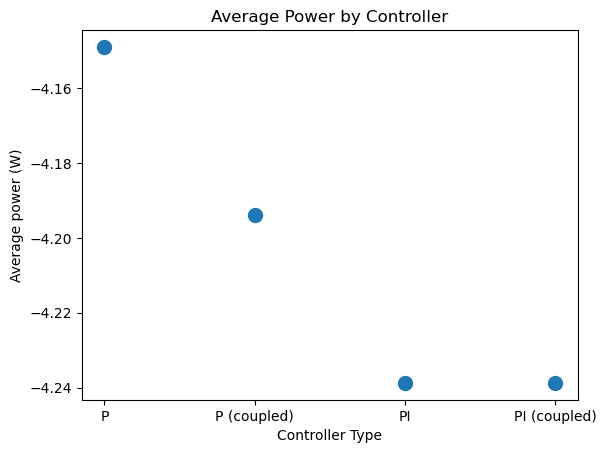

In [21]:
categories = [
    "P",
    "P (coupled)",
    "PI",
    "PI (coupled)"
]

plt.figure()
plt.scatter(categories, avg_power, s=100)
plt.ylabel("Average power (W)")
plt.xlabel("Controller Type")
plt.title("Average Power by Controller")

Optimal damping matrix: [[-172.16994877 -193.16094096]
 [-224.28824025 -160.35344645]]
Optimal stiffness matrix: [[ 28.0424004   73.68939502]
 [-26.27979908  29.46637213]]
Total avg power: [[-4.14898984]
 [-4.19393135]
 [-4.23874628]
 [-4.23874628]] W


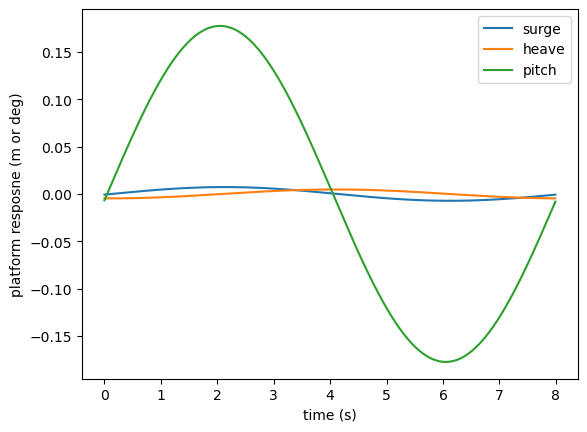

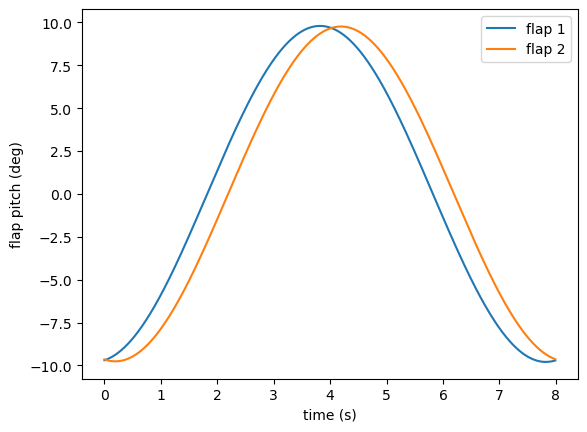

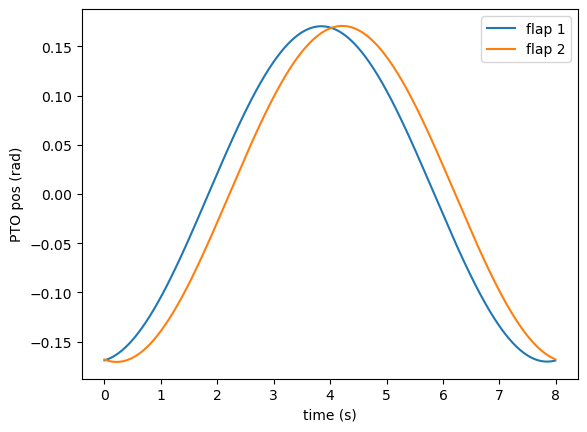

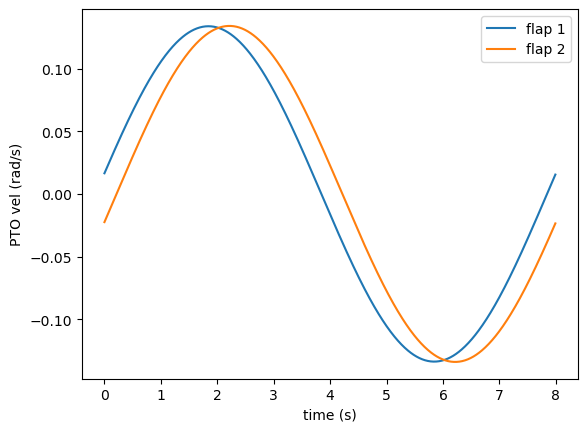

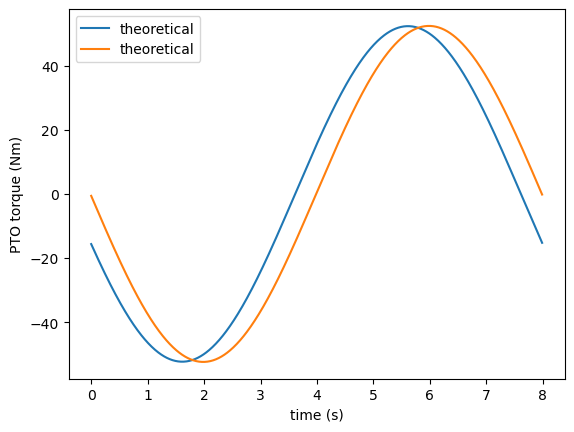

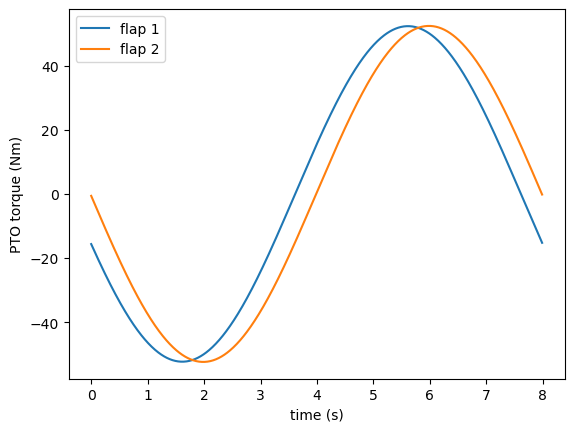

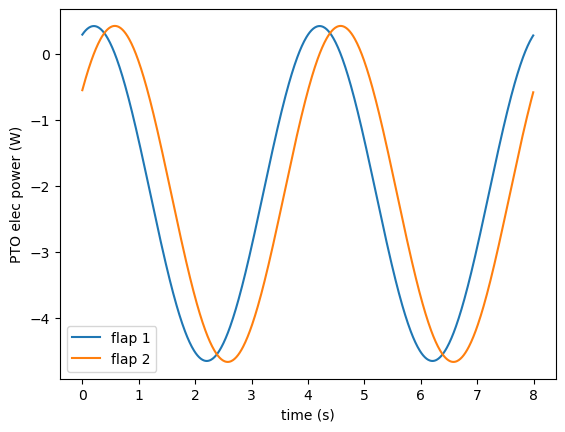

In [22]:


x_wec, x_opt = wec.decompose_state(results[0].x)
P = jnp.reshape(x_opt[:pto.ndof**2], (pto.ndof, pto.ndof)) 
I = jnp.reshape(x_opt[pto.ndof**2:], (pto.ndof, pto.ndof))
print(f'Optimal damping matrix: {P}')
print(f'Optimal stiffness matrix: {I}')

plt.figure()
plt.plot(wec_tdom['time'], wec_tdom_9dof[0,:], label='surge')
plt.plot(wec_tdom['time'], wec_tdom_9dof[1,:], label='heave')
plt.plot(wec_tdom['time'], wec_tdom_9dof[2,:]*180/np.pi, label='pitch')
plt.xlabel('time (s)')
plt.ylabel('platform resposne (m or deg)')
plt.legend()

plt.figure()
plt.plot(wec_tdom['time'], wec_tdom_9dof[5,:]*180/np.pi, label='flap 1')
plt.plot(wec_tdom['time'], wec_tdom_9dof[8,:]*180/np.pi, label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('flap pitch (deg)')
plt.legend()

plt.figure()
plt.plot(pto_tdom['time'], pto_tdom['pos'][0,:,0], label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['pos'][0,:,1], label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('PTO pos (rad)')
plt.legend()

plt.figure()
plt.plot(pto_tdom['time'], pto_tdom['vel'][0,:,0], label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['vel'][0,:,1], label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('PTO vel (rad/s)')
plt.legend()

# calculate theoretical torque
pto_force_theor = np.dot(np.squeeze(pto_tdom['vel']), P.T) + np.dot(np.squeeze(pto_tdom['pos']), I.T)

plt.figure()
plt.plot(pto_tdom['time'], pto_force_theor, label='theoretical')
plt.xlabel('time (s)')
plt.ylabel('PTO torque (Nm)')
plt.legend()

plt.figure()
plt.plot(pto_tdom['time'], pto_tdom['force'][0,:,0], label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['force'][0,:,1], label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('PTO torque (Nm)')
plt.legend()

plt.figure()
plt.plot(pto_tdom['time'], pto_tdom['power'][0,1,:,0], label='flap 1')
plt.plot(pto_tdom['time'], pto_tdom['power'][0,1,:,1], label='flap 2')
plt.xlabel('time (s)')
plt.ylabel('PTO elec power (W)')
plt.legend()


print(f'Total avg power: {avg_power} W')